# ✅ Solutions — Module 4 — Sampling, the Law of Large Numbers & the Central Limit Theorem

Worked solutions for every exercise of this module. **Try the exercise yourself first** — you learn statistics by *doing* it. Each solution ends with a short interpretation, because in real projects the numbers are only half of the answer.

*Every exercise is self-contained: run the setup cell below, then jump to any exercise.*

In [1]:
# --- Course setup (identical in every module) ---
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (9, 4.2), "figure.dpi": 90, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False})
C = sns.color_palette("deep")      # C[0] blue, C[1] orange, C[2] green, C[3] red, C[4] purple
rng = np.random.default_rng(42)    # seeded generator => reproducible results

### ✍️ Exercise 4.1 — *Standard error of a proportion*: How many people must a pollster ask? (Opinion research)

A polling institute wants to estimate the vote share $p$ of a party (true value around 30 %) in a country with 60 million voters.

**Tasks**
1. For an SRS, compute the 95 % **margin of error** $1.96\sqrt{p(1-p)/n}$ for $n$ = 100, 500, 1000, 2000, 10,000. Plot margin of error against $n$.
2. How many respondents are needed for ±2 points? For ±1 point?
3. Simulate 10,000 polls with $n = 1000$ and true $p = 0.30$. How often is a poll off by more than 3 points? Compare the simulated SE with the formula.
4. The same institute polls Luxembourg (≈ 300,000 voters). Does it need a smaller sample? Use the finite-population correction $\sqrt{(N-n)/(N-1)}$ to justify your answer.

n =    100: margin of error = ±9.0%
n =    500: margin of error = ±4.0%
n =  1,000: margin of error = ±2.8%
n =  2,000: margin of error = ±2.0%
n = 10,000: margin of error = ±0.9%
±2% needs n = 2,017
±1% needs n = 8,068

simulated SE = 0.0145 (formula 0.0145);  off by > 3 points in 4.0% of polls
N =  60,000,000: FPC = 0.99999  -> margin of error ±2.84%
N =     300,000: FPC = 0.99833  -> margin of error ±2.84%


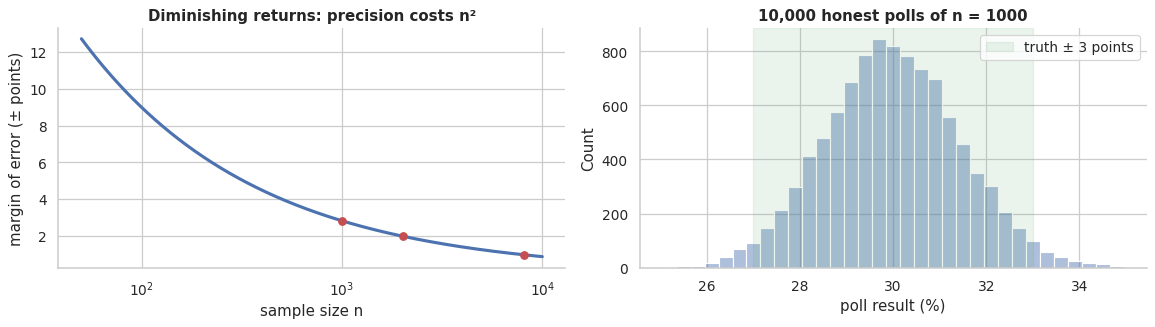

In [2]:
p = .30; moe = lambda n: 1.96 * np.sqrt(p * (1 - p) / n)
for n in [100, 500, 1000, 2000, 10_000]: print(f"n = {n:>6,}: margin of error = ±{moe(n):.1%}")
for target in [.02, .01]: print(f"±{target:.0%} needs n = {int(np.ceil(1.96 ** 2 * p * (1 - p) / target ** 2)):,}")

g = np.random.default_rng(41); polls = g.binomial(1000, p, 10_000) / 1000
print(f"\nsimulated SE = {polls.std():.4f} (formula {np.sqrt(p * (1 - p) / 1000):.4f});  off by > 3 points in {(np.abs(polls - p) > .03).mean():.1%} of polls")
for N in [60_000_000, 300_000]: print(f"N = {N:>11,}: FPC = {np.sqrt((N - 1000) / (N - 1)):.5f}  -> margin of error ±{moe(1000) * np.sqrt((N - 1000) / (N - 1)):.2%}")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 3.8)); n = np.arange(50, 10_001)
a1.plot(n, moe(n) * 100, lw=2.5, color=C[0]); a1.scatter([1000, 2017, 8068], [moe(1000) * 100, 2, 1], color=C[3], zorder=3)
a1.set(xscale="log", xlabel="sample size n", ylabel="margin of error (± points)", title="Diminishing returns: precision costs n²")
sns.histplot(polls * 100, bins=np.arange(25.05, 35.2, .3), ax=a2, color=C[0], alpha=.45); a2.axvspan(27, 33, color=C[2], alpha=.12, label="truth ± 3 points"); a2.set(xlabel="poll result (%)", title="10,000 honest polls of n = 1000"); a2.legend(); plt.tight_layout(); plt.show()

**Interpretation.** $n = 1000$ gives ≈ ±2.8 points — the reason most published polls use about a thousand respondents. ±2 points needs ≈ 2,000, ±1 point ≈ 8,100 respondents: **four times the cost for half the error**. Even a perfectly executed poll of 1000 misses by more than 3 points about 4 % of the time — so a 2-point "swing" between two polls is mostly noise.

**Population size is (almost) irrelevant:** the correction factor for Luxembourg is 0.998, so it needs practically the same sample as a country 200 times larger. Precision is governed by the absolute sample size $n$, not by the fraction $n/N$ — you do not need to drink more soup to taste a bigger pot, as long as it is well stirred (= random sampling).

### ✍️ Exercise 4.2 — *Sampling designs*: Auditing inventory with 100 store visits (Retail audit)

A retail chain has 2,000 stores in three formats. Auditors can physically count inventory in only **100 stores** and want to estimate the **mean inventory value per store**.

**Tasks**
1. Compare three designs by simulating 5,000 audits each: (a) SRS of 100 stores, (b) stratified with *proportional* allocation, (c) stratified with *Neyman* allocation $n_h \propto N_h\sigma_h$ (use the stratum standard deviations from `stores`).
2. Plot the three sampling distributions of the estimated mean. Are all designs unbiased? Report the standard errors.
3. How many stores would an SRS need to match the precision of design (c)?

In [3]:
g = np.random.default_rng(402)
fmt = np.repeat(["hypermarket", "supermarket", "convenience"], [100, 600, 1300])
value = np.concatenate([g.normal(900, 150, 100), g.normal(300, 60, 600), g.normal(60, 20, 1300)]).clip(5)   # k€
stores = pd.DataFrame({"format": fmt, "inventory_keur": value.round(1)})
stores.groupby("format").inventory_keur.agg(["count", "mean", "std"]).round(1)

,count,mean,std
format,,,
convenience,1300,59.1,20.1
hypermarket,100,911.8,168.1
supermarket,600,302.7,59.7


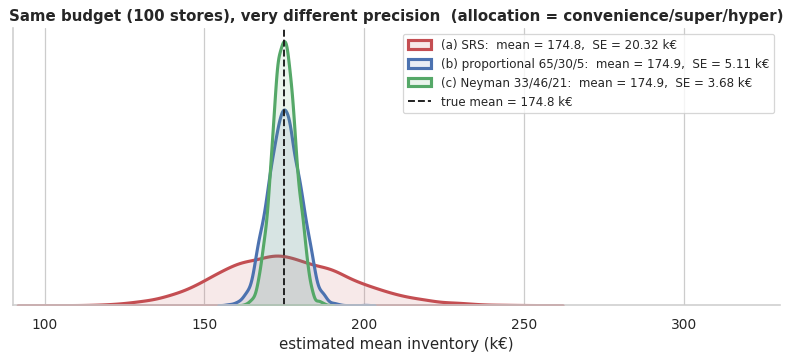

SRS needs ≈ 31× the sample size (≈ 3,051 stores — more than the chain has!) to match Neyman allocation.


In [4]:
g = np.random.default_rng(42); true_mean, n, B = stores.inventory_keur.mean(), 100, 5000
groups = {f: d.inventory_keur.to_numpy() for f, d in stores.groupby("format")}
W = {f: len(v) / len(stores) for f, v in groups.items()}                                     # stratum weights N_h / N

def stratified(alloc):                                                                       # weighted mean of the stratum means
    return sum(W[f] * np.array([g.choice(v, alloc[f], replace=False).mean() for _ in range(B)]) for f, v in groups.items())

prop = {f: int(round(n * W[f])) for f in groups}
ney_raw = {f: W[f] * groups[f].std() for f in groups}; neyman = {f: int(round(n * r / sum(ney_raw.values()))) for f, r in ney_raw.items()}
est = {"(a) SRS": np.array([g.choice(stores.inventory_keur.to_numpy(), n, replace=False).mean() for _ in range(B)]),
       f"(b) proportional {prop['convenience']}/{prop['supermarket']}/{prop['hypermarket']}": stratified(prop),
       f"(c) Neyman {neyman['convenience']}/{neyman['supermarket']}/{neyman['hypermarket']}": stratified(neyman)}     # conv./super/hyper

fig, ax = plt.subplots(figsize=(11, 4))
for (name, e), col in zip(est.items(), [C[3], C[0], C[2]]):
    sns.kdeplot(e, ax=ax, color=col, lw=2.5, fill=True, alpha=.12, label=f"{name}:  mean = {e.mean():.1f},  SE = {e.std():.2f} k€")
ax.axvline(true_mean, color="k", ls="--", label=f"true mean = {true_mean:.1f} k€"); ax.set(xlabel="estimated mean inventory (k€)", yticks=[], ylabel="", xlim=(90, 330), title="Same budget (100 stores), very different precision  (allocation = convenience/super/hyper)"); ax.legend(loc="upper right", fontsize=9.5); plt.show()
ratio = (est["(a) SRS"].std() / list(est.values())[2].std()) ** 2
print(f"SRS needs ≈ {ratio:.0f}× the sample size (≈ {100 * ratio:,.0f} stores — more than the chain has!) to match Neyman allocation.")

**Interpretation.** All three designs are unbiased (centred on the true mean ≈ 175 k€) but differ enormously in precision. SRS has an SE of ≈ 20 k€ because the *between-format* differences (60 vs 300 vs 900 k€) dominate the variance, and the number of hypermarkets in the sample varies by chance. Stratification removes the between-stratum variance entirely (SE ≈ 5 k€); Neyman allocation additionally sends more auditors to where inventory varies most — the few, highly variable hypermarkets — for an SE of ≈ 3–4 k€.

**Stratify whenever strata differ strongly in the variable of interest** — the gain can be worth more than a 20-fold increase in sample size.

### ✍️ Exercise 4.3 — *Sampling distribution of the mean*: Monitoring a bottling line (Statistical process control)

A filling machine is set to **502 ml** with σ = 4 ml (individual bottles, normally distributed). Every hour QA takes **n = 25** bottles and records the mean. The label says 500 ml.

**Tasks**
1. What is the probability that a *single* bottle contains less than 500 ml? That the *mean of 25* is below 500 ml? Plot both distributions in one figure.
2. Compute the 3-sigma **control limits** for the hourly mean $\bar x$. What is the false-alarm probability per hour when the process is fine?
3. The array `hourly` holds 60 hours × 25 bottles. Draw the $\bar x$ control chart. When does the chart signal, and what probably happened?
4. After the shift, what is the probability per hour that the chart detects it?

In [5]:
g = np.random.default_rng(403)
hourly = g.normal(502, 4, (60, 25)); hourly[38:] -= 2.2          # something happens after hour 38 ...
hourly = hourly.round(1); hourly.shape

(60, 25)

1) P(single bottle < 500) = 0.309   |   P(mean of 25 < 500) = 0.0062
2) control limits: [499.6, 504.4] ml,  false-alarm probability per hour = 0.0027 (≈ 1 in 370 hours)
3) first signal at hour 38  (all signals: [38, 41, 42, 52, 56, 58])
4) after a shift to 499.8 ml:  P(x̄ < LCL) = 0.40 per hour  -> expected detection delay ≈ 2.5 hours


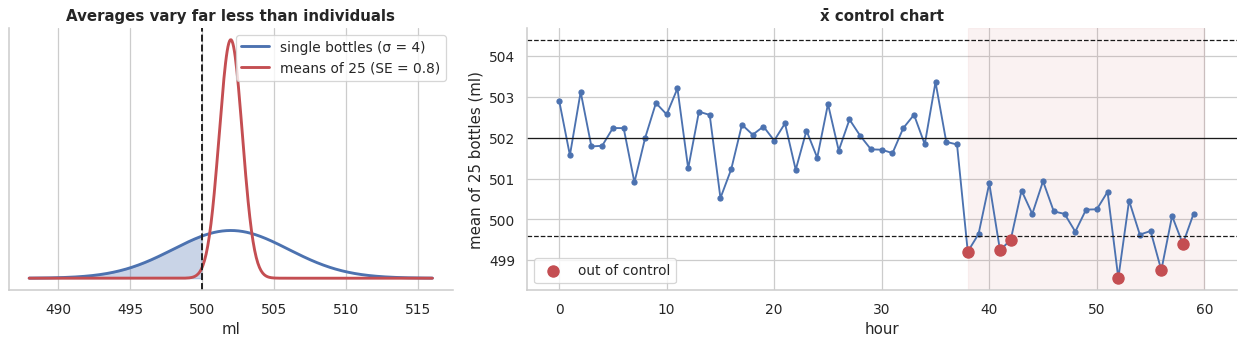

In [6]:
mu0, sigma, n = 502, 4, 25; se = sigma / np.sqrt(n)
print(f"1) P(single bottle < 500) = {stats.norm.cdf(500, mu0, sigma):.3f}   |   P(mean of 25 < 500) = {stats.norm.cdf(500, mu0, se):.4f}")
lcl, ucl = mu0 - 3 * se, mu0 + 3 * se
print(f"2) control limits: [{lcl:.1f}, {ucl:.1f}] ml,  false-alarm probability per hour = {2 * stats.norm.sf(3):.4f} (≈ 1 in {1 / (2 * stats.norm.sf(3)):.0f} hours)")
xbar = hourly.mean(axis=1); out = np.where((xbar < lcl) | (xbar > ucl))[0]
print(f"3) first signal at hour {out[0]}  (all signals: {out.tolist()})")
print(f"4) after a shift to {mu0 - 2.2:.1f} ml:  P(x̄ < LCL) = {stats.norm.cdf(lcl, mu0 - 2.2, se):.2f} per hour  -> expected detection delay ≈ {1 / stats.norm.cdf(lcl, mu0 - 2.2, se):.1f} hours")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={"width_ratios": [1, 1.6]}); x = np.linspace(488, 516, 500)
a1.plot(x, stats.norm.pdf(x, mu0, sigma), color=C[0], lw=2.3, label="single bottles (σ = 4)"); a1.plot(x, stats.norm.pdf(x, mu0, se), color=C[3], lw=2.3, label="means of 25 (SE = 0.8)")
a1.fill_between(x, stats.norm.pdf(x, mu0, sigma), where=x < 500, color=C[0], alpha=.3); a1.axvline(500, color="k", ls="--"); a1.set(title="Averages vary far less than individuals", yticks=[], xlabel="ml"); a1.legend()
a2.plot(xbar, "o-", color=C[0], ms=4); a2.scatter(out, xbar[out], color=C[3], s=80, zorder=3, label="out of control")
for v, ls in [(mu0, "-"), (lcl, "--"), (ucl, "--")]: a2.axhline(v, color="k", ls=ls, lw=1)
a2.axvspan(38, 60, color=C[3], alpha=.07); a2.set(xlabel="hour", ylabel="mean of 25 bottles (ml)", title="x̄ control chart"); a2.legend(); plt.tight_layout(); plt.show()

**Interpretation.** About 31 % of *individual* bottles are under-filled, but the *mean of 25* falls below 500 ml in fewer than 1 % of hours — averaging shrinks the spread by $\sqrt{25} = 5$. The control limits 502 ± 2.4 ml produce a false alarm only about once in 370 hours. After hour 38 the process mean dropped by ≈ 2 ml (e.g. a worn nozzle or a viscosity change): single bottle weights would hardly reveal it (shift ≈ 0.5σ), but on the scale of the mean it is a shift of almost 3 standard errors, caught with ≈ 40 % probability each hour — i.e. typically within two to three hours.

This is the entire idea of Shewhart control charts: **the sampling distribution of the mean tells you which fluctuations are noise and which are signal.**

### ✍️ Exercise 4.4 — *CLT in practice*: Can we trust normal-theory alerts on skewed latency? (Site reliability engineering)

An API has lognormal latencies (median ≈ 100 ms, heavy right tail). The monitoring system averages the latency of $n$ requests and raises an alert when the average exceeds $\mu + 3\,\sigma/\sqrt n$ — which "should" happen with probability 0.00135 if the average were normal.

**Tasks**
1. For $n$ = 5, 30, 200, 2000 simulate 100,000 averages. Plot their distributions with the normal approximation.
2. For each $n$ report the skewness of the averages and the **actual** false-alarm rate. By what factor is it off?
3. Propose two ways to obtain alerts with a reliable false-alarm rate.

In [7]:
lat = stats.lognorm(s=0.9, scale=100)                     # latency distribution in ms
print(f"median = {lat.median():.0f} ms, mean = {lat.mean():.0f} ms, sd = {lat.std():.0f} ms, skewness = {float(lat.stats('s')):.1f}")

median = 100 ms, mean = 150 ms, sd = 167 ms, skewness = 4.7


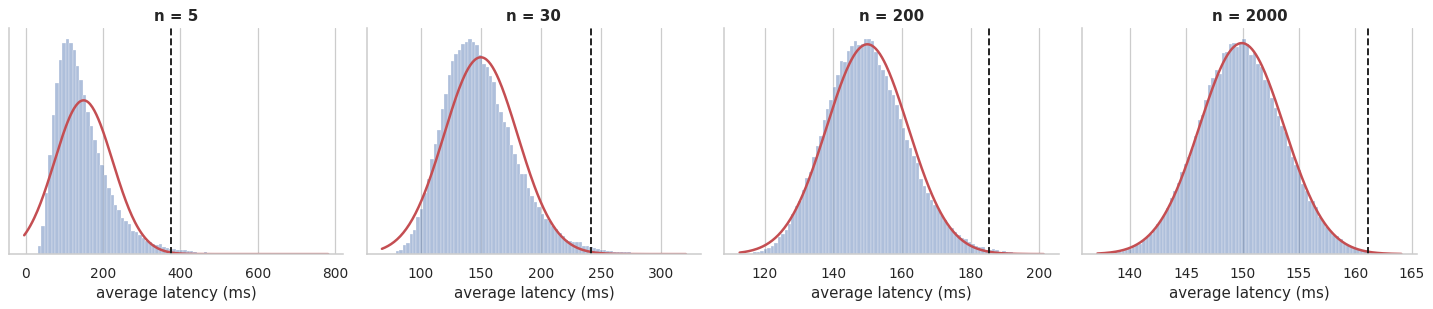

,skewness of mean,false-alarm rate,× nominal (0.00135)
n,,,
5,2.0341,0.0153,11.3556
30,0.8448,0.0091,6.7111
200,0.3462,0.0046,3.3778
2000,0.0944,0.0019,1.4296


In [8]:
mu, sd = lat.mean(), lat.std(); fig, axes = plt.subplots(1, 4, figsize=(16, 3.6)); rows = []
for ax, n in zip(axes, [5, 30, 200, 2000]):
    m = np.concatenate([lat.rvs((20_000, n), random_state=404 + i).mean(axis=1) for i in range(5)])        # 100,000 averages
    thr = mu + 3 * sd / np.sqrt(n); far = (m > thr).mean()
    rows.append({"n": n, "skewness of mean": stats.skew(m), "false-alarm rate": far, "× nominal (0.00135)": far / .00135})
    sns.histplot(m, bins=80, stat="density", ax=ax, color=C[0], alpha=.45, binrange=(np.quantile(m, .0005), np.quantile(m, .9995)))
    xx = np.linspace(*ax.get_xlim(), 300); ax.plot(xx, stats.norm.pdf(xx, mu, sd / np.sqrt(n)), color=C[3], lw=2); ax.axvline(thr, color="k", ls="--")
    ax.set(title=f"n = {n}", yticks=[], ylabel="", xlabel="average latency (ms)")
plt.tight_layout(); plt.show()
pd.DataFrame(rows).set_index("n").round(4)

**Interpretation.** The parent skewness of ≈ 5 decays only like $1/\sqrt n$: at $n = 5$ the alert fires about eleven times and at $n = 30$ still roughly **seven times more often** than the nominal 0.135 %; even at $n = 200$ it is more than three times too high. Only in the thousands does the normal approximation become acceptable *in the tail* (the centre looks fine much earlier — tails converge last).

**Remedies:** (1) alert on the mean of **log-latency** (normal already for single requests) or on the *median / a percentile*; (2) calibrate the threshold **empirically** from historical averages or by bootstrap instead of $\mu + 3\,\text{SE}$; (3) average over more requests. The "n ≥ 30" folklore fails badly for heavy right tails — precisely the data typical of latencies, costs and losses.

### ✍️ Exercise 4.5 — *Sampling bias*: A satisfaction survey with 9,000 answers — and the wrong result (Customer insights)

A streaming service e-mails a satisfaction survey (score 1–10) to all 50,000 customers. 9,000 respond. The CRM system knows each customer's **age segment**, and (in this simulated world) we also know everyone's true score.

**Tasks**
1. Compare the true mean satisfaction with the mean of the respondents. How large is the bias compared with the (naive) standard error?
2. Would 20,000 responses help? Explain using "bias vs. standard error".
3. Compare the segment mix among respondents with the customer base, then compute a **post-stratified** estimate (weight each segment's mean by its population share).
4. Under which circumstances would weighting *not* fix the problem?

In [9]:
g = np.random.default_rng(405); Ncust = 50_000
segment = g.choice(["18–34", "35–54", "55+"], Ncust, p=[.45, .35, .20])
score = np.clip(np.round(g.normal(pd.Series(segment).map({"18–34": 6.0, "35–54": 7.2, "55+": 8.4}), 1.6)), 1, 10)
responded = g.random(Ncust) < pd.Series(segment).map({"18–34": .07, "35–54": .18, "55+": .45}).to_numpy()
customers = pd.DataFrame({"segment": segment, "score": score, "responded": responded})
print(f"{responded.sum():,} of {Ncust:,} customers responded"); customers.head()

9,197 of 50,000 customers responded


,segment,score,responded
0,55+,9.0,False
1,18–34,6.0,False
2,35–54,10.0,False
3,55+,8.0,False
4,35–54,6.0,False


1) true mean = 6.85 | respondents' mean = 7.50 ± 0.018 (SE)  ->  bias = +0.64 = 36 standard errors!


,share of customers,share of respondents,mean score (respondents)
segment,,,
18–34,0.451,0.172,5.982
35–54,0.349,0.337,7.131
55+,0.199,0.491,8.275


3) post-stratified estimate = 6.83   (truth 6.85)


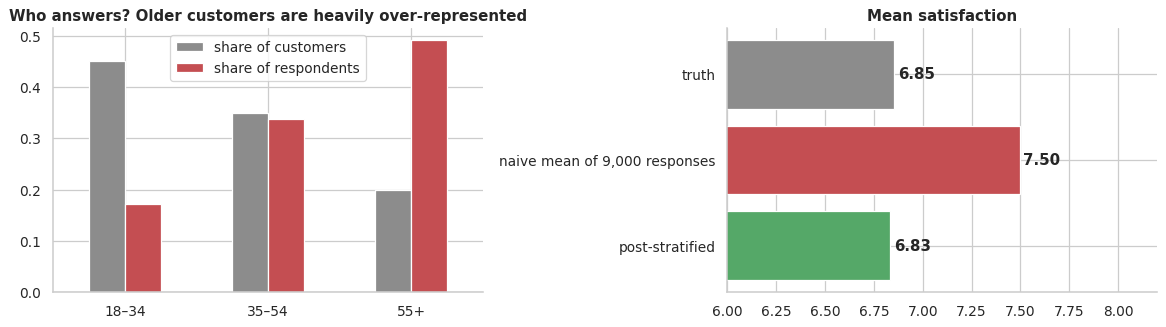

In [10]:
resp = customers[customers.responded]; true_mean = customers.score.mean()
naive, se = resp.score.mean(), resp.score.std() / np.sqrt(len(resp))
print(f"1) true mean = {true_mean:.2f} | respondents' mean = {naive:.2f} ± {se:.3f} (SE)  ->  bias = {naive - true_mean:+.2f} = {abs(naive - true_mean) / se:.0f} standard errors!")
mix = pd.DataFrame({"share of customers": customers.segment.value_counts(normalize=True), "share of respondents": resp.segment.value_counts(normalize=True),
                    "mean score (respondents)": resp.groupby("segment").score.mean()}).round(3)
display(mix)
post = (mix["share of customers"] * mix["mean score (respondents)"]).sum()
print(f"3) post-stratified estimate = {post:.2f}   (truth {true_mean:.2f})")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 3.8))
mix[["share of customers", "share of respondents"]].plot.bar(ax=a1, color=[C[7], C[3]], rot=0); a1.set(title="Who answers? Older customers are heavily over-represented", xlabel="")
a2.barh(["truth", "naive mean of 9,000 responses", "post-stratified"], [true_mean, naive, post], color=[C[7], C[3], C[2]])
for i, v in enumerate([true_mean, naive, post]): a2.text(v + .02, i, f"{v:.2f}", va="center", fontweight="bold")
a2.set(xlim=(6, 8.2), title="Mean satisfaction"); a2.invert_yaxis(); plt.tight_layout(); plt.show()

**Interpretation.** The naive estimate is wrong by about +0.6 points — dozens of standard errors. The tiny SE creates a false sense of precision: **a large biased sample is "precisely wrong"**. More responses shrink the SE, not the bias; the survey would just converge more confidently to the wrong number (the Literary Digest effect).

Because older, happier customers respond far more often, re-weighting the segment means with the *known* population shares (**post-stratification**) recovers the truth almost exactly.

**Limits:** weighting only repairs bias that is explained by *observed* variables. If, *within* a segment, unhappy customers respond more (or less) often than happy ones — non-response that depends on the unobserved answer itself — no weighting scheme can fix it. Then you need a better design: random follow-ups of non-respondents, incentives, or mandatory in-app micro-surveys.